# 🌲 Isolation Forest — Kredi Kartı Dolandırıcılığı Tespiti

**Isolation Forest**, anormal noktaları **erken izole etme** prensibine dayanan bir anomali tespit algoritmasıdır.
Fikir şudur: **Anormal noktalar azdır ve diğerlerinden uzak durur** → rastgele bölmelerle çabuk yalnız kalırlar.

---

### 🧠 Temel Sezgi

Bir ormanda rastgele çizgiler çektiğini düşün:
- **Normal nokta** → kalabalık bölgede, izole edilmesi çok bölme gerektirir (derin ağaç)
- **Anormal nokta** → ıssız bölgede, az bölmeyle hemen izole edilir (sığ ağaç)

```
Normal:   ●●●●●●●●   → derin ağaç (izole etmek zor)
Anormal:  ●          → sığ ağaç  (izole etmek kolay)
```

---

### 📌 Veri Seti

**Credit Card Fraud Detection** (Kaggle) — Avrupalı kart sahiplerinin 2013 yılındaki işlemleri.
- 284.807 işlem, sadece 492 tanesi dolandırıcılık (%0.17)
- Özellikler `V1..V28` PCA ile dönüştürülmüş (gizlilik nedeniyle), `Amount` işlem tutarı
- `Class`: 0 = normal işlem, 1 = dolandırıcılık

> `creditcard.csv` dosyasını `../data/` klasörüne yerleştirin (bkz. `data/README.md`): https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


## 📦 1. Kütüphanelerin İçe Aktarılması

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)

print("✅ Tüm kütüphaneler başarıyla yüklendi.")

✅ Tüm kütüphaneler başarıyla yüklendi.


## 🗂️ 2. Veri Setinin Yüklenmesi

Gerçek dünya senaryosu: **kredi kartı işlem kayıtları**
- Eğitim: yalnızca normal (dolandırıcılık olmayan) işlemler
- Test: normal + dolandırıcılık işlemleri (karışık)

In [2]:
df = pd.read_csv("../data/creditcard.csv")

print(f"Veri seti boyutu : {df.shape}")
print(f"\nSınıf dağılımı:")
print(df["Class"].value_counts())
print(f"\nDolandırıcılık oranı : %{df['Class'].mean()*100:.3f}")

df.head()

Veri seti boyutu : (284807, 31)

Sınıf dağılımı:
Class
0    284315
1       492
Name: count, dtype: int64

Dolandırıcılık oranı : %0.173


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## ✂️ 3. Eğitim / Test Ayrımı

Isolation Forest yalnızca **normal** verilerle eğitilecek.
Test setine hem kalan normal işlemler hem de **tüm dolandırıcılık** kayıtları eklenecek.

In [3]:
np.random.seed(42)

normal = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]

train_normal, test_normal = train_test_split(normal, test_size=0.30, random_state=42)

test_df = pd.concat([test_normal, fraud])

features = [c for c in df.columns if c not in ["Time", "Class"]]

X_train = train_normal[features].values
X_test = test_df[features].values

y_true = np.where(test_df["Class"].values == 0, 1, -1)

print(f"Eğitim seti    : {X_train.shape}  → {len(X_train)} normal işlem")
print(f"Test  seti     : {X_test.shape}  → {len(test_normal)} normal + {len(fraud)} dolandırıcılık")
print(f"Anomali oranı  : %{len(fraud)/len(test_df)*100:.2f}")

Eğitim seti    : (199020, 29)  → 199020 normal işlem
Test  seti     : (85787, 29)  → 85295 normal + 492 dolandırıcılık
Anomali oranı  : %0.57


## ⚖️ 4. Özellik Ölçekleme

`StandardScaler`: her özelliği **ortalama=0, standart sapma=1** yaparak ölçekler.

> **Not:** Isolation Forest ağaç tabanlı olduğundan ölçeklemeye One-Class SVM kadar duyarlı değildir.
> Yine de tutarlılık ve iyi pratik için ölçekleme yapıyoruz.

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Eğitim — Ortalama : {X_train_scaled.mean(axis=0)[:5].round(6)}  (≈ 0 olmalı)")
print(f"Eğitim — Std Dev  : {X_train_scaled.std(axis=0)[:5].round(6)}  (≈ 1 olmalı)")
print("\n✅ Ölçekleme tamamlandı.")

Eğitim — Ortalama : [-0. -0. -0.  0.  0.]  (≈ 0 olmalı)
Eğitim — Std Dev  : [1. 1. 1. 1. 1.]  (≈ 1 olmalı)

✅ Ölçekleme tamamlandı.


## 📊 5. Ham Veri Görselleştirmesi

30 boyutlu veriyi görebilmek için **PCA** ile 2 boyuta indirgiyoruz (sadece görselleştirme amacıyla).

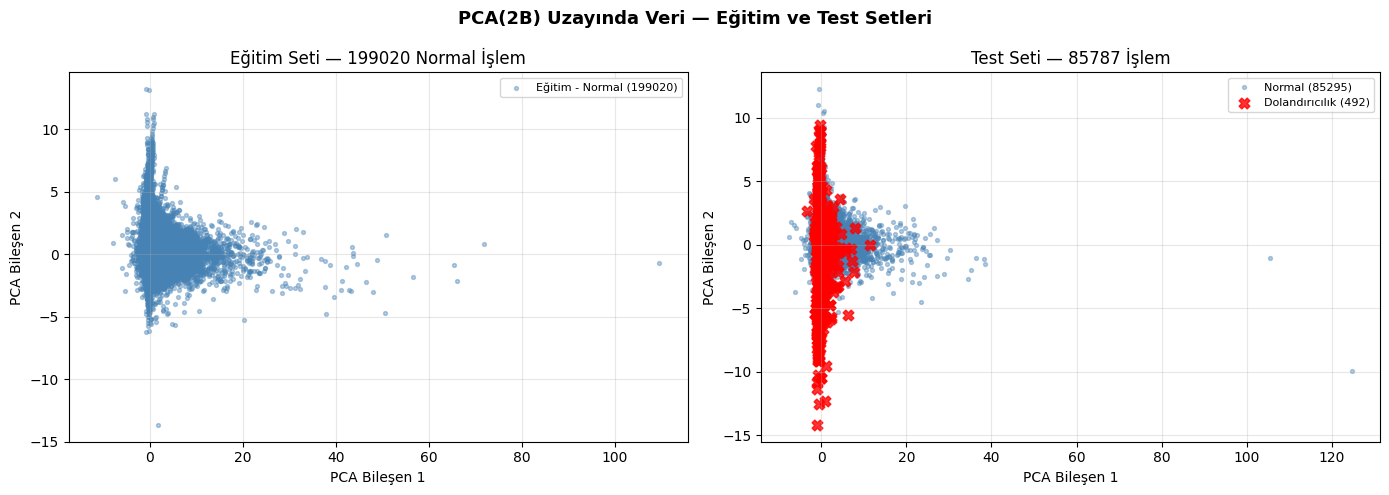

📸 ham_veri.png kaydedildi


In [5]:
pca_viz = PCA(n_components=2, random_state=42)
X_train_pca = pca_viz.fit_transform(X_train_scaled)
X_test_pca = pca_viz.transform(X_test_scaled)

test_normal_mask = y_true == 1
test_fraud_mask = y_true == -1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA(2B) Uzayında Veri — Eğitim ve Test Setleri", fontsize=13, fontweight="bold")

ax = axes[0]
ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
           c="steelblue", s=8, alpha=0.4, label=f"Eğitim - Normal ({len(X_train_pca)})")
ax.set_title(f"Eğitim Seti — {len(X_train_pca)} Normal İşlem")
ax.set_xlabel("PCA Bileşen 1")
ax.set_ylabel("PCA Bileşen 2")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(X_test_pca[test_normal_mask, 0], X_test_pca[test_normal_mask, 1],
           c="steelblue", s=8, alpha=0.4, label=f"Normal ({test_normal_mask.sum()})")
ax.scatter(X_test_pca[test_fraud_mask, 0], X_test_pca[test_fraud_mask, 1],
           c="red", marker="X", s=60, alpha=0.8, label=f"Dolandırıcılık ({test_fraud_mask.sum()})")
ax.set_title(f"Test Seti — {len(X_test_pca)} İşlem")
ax.set_xlabel("PCA Bileşen 1")
ax.set_ylabel("PCA Bileşen 2")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ham_veri.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 ham_veri.png kaydedildi")

## 🌲 6. Isolation Forest — Algoritma Mantığı

### Nasıl Çalışır?

1. **Rastgele Bölme Ağacı (iTrees)** oluşturur:
   - Rastgele bir özellik seç
   - O özelliğin min–max aralığında rastgele bir eşik değeri seç
   - Veriyi ikiye böl, derinleştir

2. **İzolasyon Derinliği** ölçülür:
   - Bir nokta kaç adımda yalnız kalıyor? → **Anomali Skoru**
   - Az adım = sığ ağaç = **anomali**
   - Çok adım = derin ağaç = **normal**

3. **Orman** = `n_estimators` adet iTrees'in ortalaması

| Hiperparametre | Açıklama | Tipik Değer |
|---|---|---|
| `n_estimators` | Ağaç sayısı | 100–200 |
| `contamination` | Beklenen anomali oranı | 0.001–0.01 (nadir dolandırıcılık) |
| `max_samples` | Her ağaç için örneklem sayısı | `'auto'` = min(256, n) |
| `max_features` | Her bölmede kullanılan özellik sayısı | 1.0 (tümü) |

In [6]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.002,
    max_samples="auto",
    max_features=1.0,
    n_jobs=-1,
    random_state=42
)

print("✅ Isolation Forest modeli oluşturuldu:")
print(f"   Ağaç sayısı      : {model.n_estimators}")
print(f"   Contamination    : {model.contamination}")
print(f"   Max samples      : {model.max_samples}")

✅ Isolation Forest modeli oluşturuldu:
   Ağaç sayısı      : 200
   Contamination    : 0.002
   Max samples      : auto


## 🏋️ 7. Modeli Eğitme

> One-Class SVM gibi, Isolation Forest da **yalnızca normal veriyle** eğitilir.
> Etiket `(y)` verilmez → **gözetimsiz (unsupervised)** öğrenme.

In [7]:
model.fit(X_train_scaled)

train_preds = model.predict(X_train_scaled)

n_inliers = (train_preds == 1).sum()
n_outliers = (train_preds == -1).sum()

print(f"✅ Model eğitildi — {len(X_train_scaled)} işlemle, {model.n_estimators} ağaç")
print(f"\nEğitim verisi üzerindeki sonuçlar:")
print(f"  Normal  (+1): {n_inliers}")
print(f"  Anormal (-1): {n_outliers}  ← contamination={model.contamination} → beklenen ≈ {int(len(X_train)*model.contamination)}")

✅ Model eğitildi — 199020 işlemle, 200 ağaç

Eğitim verisi üzerindeki sonuçlar:
  Normal  (+1): 198621
  Anormal (-1): 399  ← contamination=0.002 → beklenen ≈ 398


## 🔮 8. Test Verisi Üzerinde Tahmin ve Anomali Skorları

Isolation Forest iki tür çıktı üretir:
- `predict()` → ikili karar: **+1** (normal) veya **-1** (anomali)
- `score_samples()` → sürekli anomali skoru (düşük = daha anormal)

In [8]:
y_pred = model.predict(X_test_scaled)

anomaly_scores = model.score_samples(X_test_scaled)
anomaly_scores_pos = -anomaly_scores

TP = ((y_pred == 1) & (y_true == 1)).sum()
TN = ((y_pred == -1) & (y_true == -1)).sum()
FP = ((y_pred == 1) & (y_true == -1)).sum()
FN = ((y_pred == -1) & (y_true == 1)).sum()

accuracy = (y_pred == y_true).mean() * 100
precision = TN / (TN + FP) if (TN + FP) > 0 else 0
recall = TN / (TN + FN) if (TN + FN) > 0 else 0

y_true_bin = (y_true == -1).astype(int)
auc = roc_auc_score(y_true_bin, anomaly_scores_pos)

print("📊 TEST SONUÇLARI")
print("=" * 45)
print(f"Genel Doğruluk      : %{accuracy:.2f}")
print(f"Dolandırıcılık Precision : %{precision*100:.1f}")
print(f"Dolandırıcılık Recall    : %{recall*100:.1f}")
print(f"ROC-AUC Skoru       : {auc:.4f}  (1.0 = mükemmel)")
print()
print(f"TP={TP} | TN={TN} | FP={FP} | FN={FN}")
print()
print(f"Anomali skoru — Min: {anomaly_scores_pos.min():.4f} | Maks: {anomaly_scores_pos.max():.4f} | Ort: {anomaly_scores_pos.mean():.4f}")

📊 TEST SONUÇLARI
Genel Doğruluk      : %99.41
Dolandırıcılık Precision : %27.6
Dolandırıcılık Recall    : %47.6
ROC-AUC Skoru       : 0.9476  (1.0 = mükemmel)

TP=85145 | TN=136 | FP=356 | FN=150

Anomali skoru — Min: 0.3456 | Maks: 0.7810 | Ort: 0.4032


## 📈 9. Anomali Skorlarının Dağılımı

Normal ve dolandırıcılık işlemlerinin skor dağılımlarını karşılaştıralım.
İdeal modelde bu iki dağılım **belirgin şekilde ayrışır**.

/tmp/ipykernel_497/320434796.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


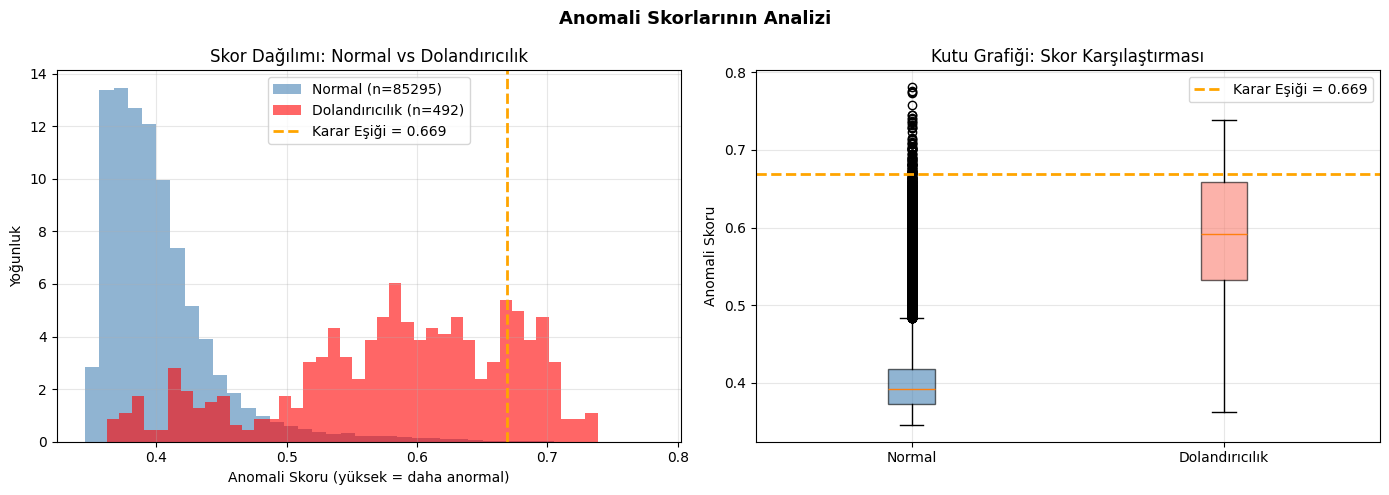

📸 skor_dagilimi.png kaydedildi


In [9]:
scores_normal = anomaly_scores_pos[y_true == 1]
scores_fraud = anomaly_scores_pos[y_true == -1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Anomali Skorlarının Analizi", fontsize=13, fontweight="bold")

ax = axes[0]
ax.hist(scores_normal, bins=40, alpha=0.6, color="steelblue",
        label=f"Normal (n={len(scores_normal)})", density=True)
ax.hist(scores_fraud, bins=40, alpha=0.6, color="red",
        label=f"Dolandırıcılık (n={len(scores_fraud)})", density=True)

threshold = np.percentile(anomaly_scores_pos, (1 - model.contamination) * 100)
ax.axvline(x=threshold, color="orange", linestyle="--", linewidth=2,
           label=f"Karar Eşiği = {threshold:.3f}")

ax.set_xlabel("Anomali Skoru (yüksek = daha anormal)")
ax.set_ylabel("Yoğunluk")
ax.set_title("Skor Dağılımı: Normal vs Dolandırıcılık")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
bp = ax.boxplot(
    [scores_normal, scores_fraud],
    labels=["Normal", "Dolandırıcılık"],
    patch_artist=True,
    notch=False,
    showfliers=True
)

bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor("salmon")
bp["boxes"][1].set_alpha(0.6)

ax.axhline(y=threshold, color="orange", linestyle="--", linewidth=2,
           label=f"Karar Eşiği = {threshold:.3f}")
ax.set_ylabel("Anomali Skoru")
ax.set_title("Kutu Grafiği: Skor Karşılaştırması")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("skor_dagilimi.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 skor_dagilimi.png kaydedildi")

## 🗺️ 10. PCA(2B) Uzayında Karar Sınırı ve Tespit Sonuçları

Gerçek model 30 boyutlu uzayda çalışır; karar yüzeyini görebilmek için **yalnızca görselleştirme amacıyla**
aynı mimaride ikinci bir Isolation Forest, PCA ile indirgenmiş 2 boyutlu veri üzerinde eğitilir.

/tmp/ipykernel_497/1357587543.py:53: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_497/1357587543.py:53: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/tmp/ipykernel_497/1357587543.py:54: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("karar_siniri.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_497/1357587543.py:54: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("karar_siniri.png", dpi=150, bbox_inches="tight")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


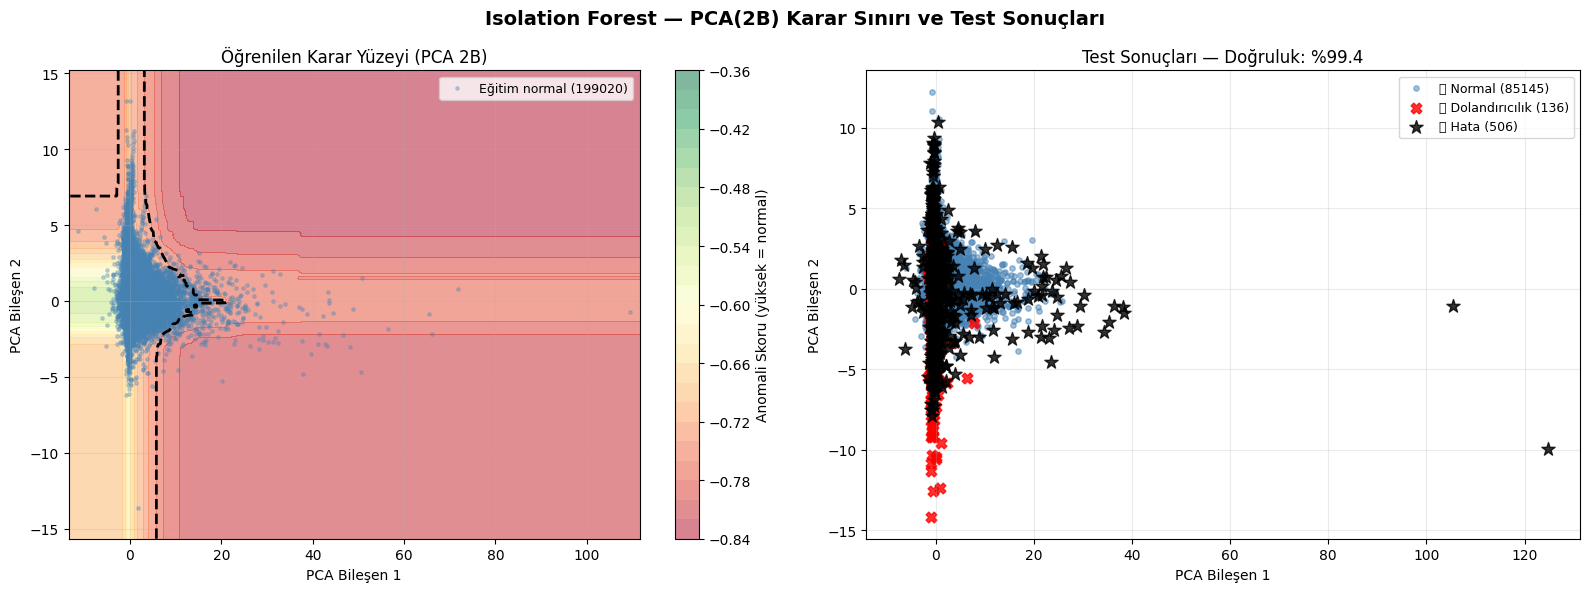

📸 karar_siniri.png kaydedildi


In [10]:
viz_model = IsolationForest(n_estimators=200, contamination=0.002, random_state=42, n_jobs=-1)
viz_model.fit(X_train_pca)

xx, yy = np.meshgrid(
    np.linspace(X_train_pca[:, 0].min() - 2, X_train_pca[:, 0].max() + 2, 300),
    np.linspace(X_train_pca[:, 1].min() - 2, X_train_pca[:, 1].max() + 2, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = viz_model.score_samples(grid_points)
Z = Z.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Isolation Forest — PCA(2B) Karar Sınırı ve Test Sonuçları",
             fontsize=14, fontweight="bold")

ax1 = axes[0]
cf = ax1.contourf(xx, yy, Z, levels=25, cmap="RdYlGn", alpha=0.5)
plt.colorbar(cf, ax=ax1, label="Anomali Skoru (yüksek = normal)")

decision_threshold = np.percentile(viz_model.score_samples(X_train_pca), viz_model.contamination * 100)
ax1.contour(xx, yy, Z, levels=[decision_threshold],
            linewidths=2, colors="black", linestyles="--")

ax1.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            c="steelblue", s=6, alpha=0.3, label=f"Eğitim normal ({len(X_train_pca)})")

ax1.set_title("Öğrenilen Karar Yüzeyi (PCA 2B)")
ax1.set_xlabel("PCA Bileşen 1")
ax1.set_ylabel("PCA Bileşen 2")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

ax2 = axes[1]
correct = y_pred == y_true
wrong = ~correct

mask = correct & (y_true == 1)
ax2.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
            c="steelblue", s=15, alpha=0.5, label=f"✅ Normal ({mask.sum()})")
mask = correct & (y_true == -1)
ax2.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
            c="red", marker="X", s=60, alpha=0.8, label=f"✅ Dolandırıcılık ({mask.sum()})")
ax2.scatter(X_test_pca[wrong, 0], X_test_pca[wrong, 1],
            c="black", marker="*", s=100, alpha=0.8, label=f"❌ Hata ({wrong.sum()})", zorder=6)

ax2.set_title(f"Test Sonuçları — Doğruluk: %{accuracy:.1f}")
ax2.set_xlabel("PCA Bileşen 1")
ax2.set_ylabel("PCA Bileşen 2")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("karar_siniri.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 karar_siniri.png kaydedildi")

## 🔬 11. Contamination Parametresinin Etkisi

`contamination`: verideki beklenen anomali oranı tahmini.
Bu değer karar eşiğini (threshold) doğrudan etkiler:
- Çok düşük → az şey anomali sayılır → yüksek FN riski
- Çok yüksek → çok şey anomali sayılır → yüksek FP riski

In [11]:
contamination_values = [0.001, 0.002, 0.005, 0.01, 0.02]

results_cont = []

for cont in contamination_values:
    m = IsolationForest(
        n_estimators=200,
        contamination=cont,
        random_state=42,
        n_jobs=-1
    )
    m.fit(X_train_scaled)
    preds = m.predict(X_test_scaled)

    tp = ((preds == 1) & (y_true == 1)).sum()
    tn = ((preds == -1) & (y_true == -1)).sum()
    fp = ((preds == 1) & (y_true == -1)).sum()
    fn = ((preds == -1) & (y_true == 1)).sum()
    acc = (preds == y_true).mean() * 100
    rec = tn / (tn + fn) * 100 if (tn + fn) > 0 else 0

    results_cont.append({
        "cont": cont, "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Acc": acc, "Recall": rec
    })

print("┌────────────┬───────┬──────┬──────┬──────┬──────────┬────────────────┐")
print("│ contaminat │  TP   │  TN  │  FP  │  FN  │ Doğruluk │ Dolandırıcılık │")
print("│            │       │      │      │      │          │     Recall     │")
print("├────────────┼───────┼──────┼──────┼──────┼──────────┼────────────────┤")
for r in results_cont:
    marker = " ◀" if abs(r["cont"] - 0.002) < 0.0001 else "  "
    print(f"│   {r['cont']:.3f}   │ {r['TP']:5d} │ {r['TN']:4d} │ {r['FP']:4d} │ {r['FN']:4d} │  %{r['Acc']:5.2f}  │    %{r['Recall']:5.1f}     │{marker}")
print("└────────────┴───────┴──────┴──────┴──────┴──────────┴────────────────┘")
print("\n◀ Seçilen değer | TP=Doğru Normal | TN=Doğru Dolandırıcılık | FP=Kaçan | FN=Yanlış Alarm")

┌────────────┬───────┬──────┬──────┬──────┬──────────┬────────────────┐
│ contaminat │  TP   │  TN  │  FP  │  FN  │ Doğruluk │ Dolandırıcılık │
│            │       │      │      │      │          │     Recall     │
├────────────┼───────┼──────┼──────┼──────┼──────────┼────────────────┤
│   0.001   │ 85223 │   93 │  399 │   72 │  %99.45  │    % 56.4     │  
│   0.002   │ 85145 │  136 │  356 │  150 │  %99.41  │    % 47.6     │ ◀
│   0.005   │ 84881 │  203 │  289 │  414 │  %99.18  │    % 32.9     │  
│   0.010   │ 84440 │  282 │  210 │  855 │  %98.76  │    % 24.8     │  
│   0.020   │ 83584 │  355 │  137 │ 1711 │  %97.85  │    % 17.2     │  
└────────────┴───────┴──────┴──────┴──────┴──────────┴────────────────┘

◀ Seçilen değer | TP=Doğru Normal | TN=Doğru Dolandırıcılık | FP=Kaçan | FN=Yanlış Alarm


## 🌲 12. Isolation Forest vs One-Class SVM Karşılaştırması

One-Class SVM büyük veri setinde çok yavaş olduğu için karşılaştırmayı küçük bir örneklem üzerinde yapıyoruz.

/tmp/ipykernel_497/2707895758.py:65: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_497/2707895758.py:65: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_497/2707895758.py:66: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("karsilastirma.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_497/2707895758.py:66: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("karsilastirma.png", dpi=150, bbox_inches="tight")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


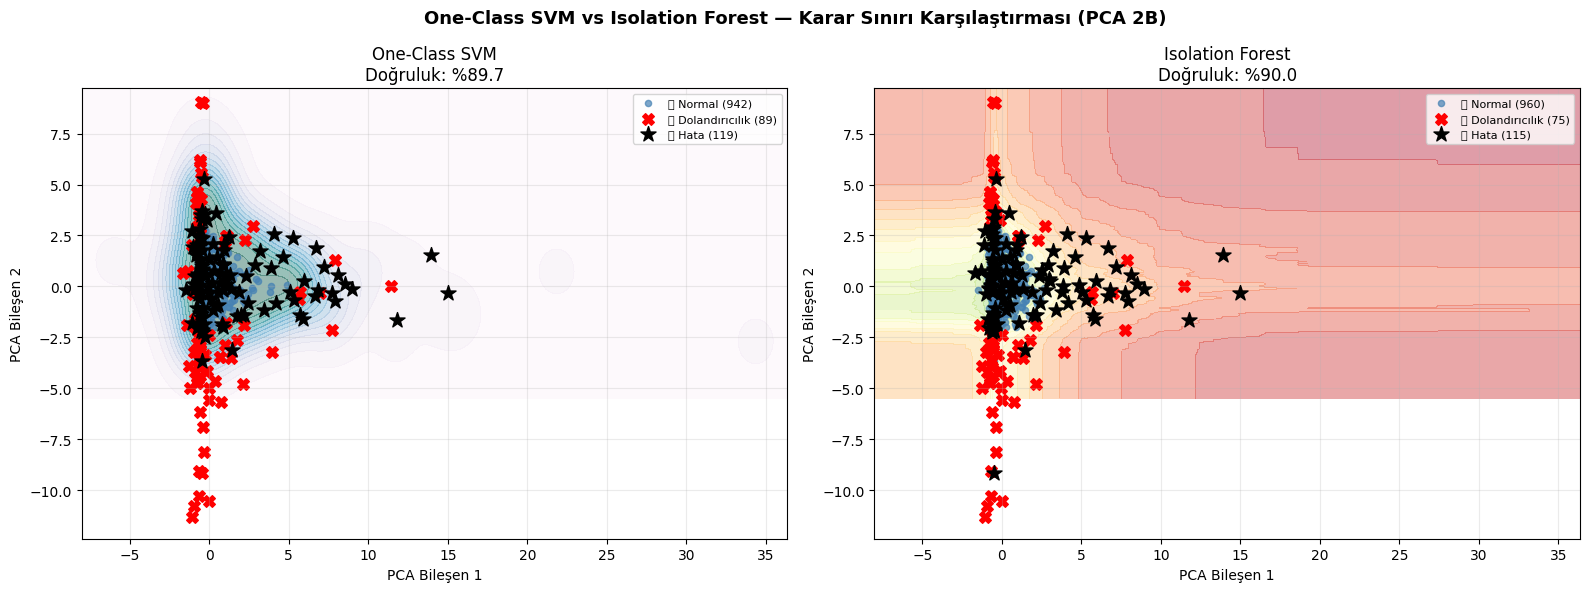

📸 karsilastirma.png kaydedildi


In [12]:
from sklearn.svm import OneClassSVM

normal_sample = normal.sample(n=4000, random_state=42)
fraud_sample = fraud.sample(n=150, random_state=42)

cmp_train, cmp_test_normal = train_test_split(normal_sample, test_size=0.25, random_state=42)
cmp_test = pd.concat([cmp_test_normal, fraud_sample])

X_cmp_train = scaler.transform(cmp_train[features].values)
X_cmp_test = scaler.transform(cmp_test[features].values)
y_cmp_true = np.where(cmp_test["Class"].values == 0, 1, -1)

X_cmp_train_pca = pca_viz.transform(X_cmp_train)
X_cmp_test_pca = pca_viz.transform(X_cmp_test)

ocsvm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
ocsvm.fit(X_cmp_train_pca)
pred_svm = ocsvm.predict(X_cmp_test_pca)
acc_svm = (pred_svm == y_cmp_true).mean() * 100

iforest = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
iforest.fit(X_cmp_train_pca)
pred_if = iforest.predict(X_cmp_test_pca)
acc_if = (pred_if == y_cmp_true).mean() * 100

xx_c, yy_c = np.meshgrid(
    np.linspace(X_cmp_train_pca[:, 0].min() - 2, X_cmp_train_pca[:, 0].max() + 2, 300),
    np.linspace(X_cmp_train_pca[:, 1].min() - 2, X_cmp_train_pca[:, 1].max() + 2, 300)
)
grid_cmp = np.c_[xx_c.ravel(), yy_c.ravel()]

Z_svm = ocsvm.decision_function(grid_cmp).reshape(xx_c.shape)
Z_if = iforest.score_samples(grid_cmp).reshape(xx_c.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("One-Class SVM vs Isolation Forest — Karar Sınırı Karşılaştırması (PCA 2B)",
             fontsize=13, fontweight="bold")

models_data = [
    ("One-Class SVM", Z_svm, pred_svm, acc_svm, "PuBuGn"),
    ("Isolation Forest", Z_if, pred_if, acc_if, "RdYlGn"),
]

for ax, (name, Z_val, preds, acc_val, cmap) in zip(axes, models_data):
    ax.contourf(xx_c, yy_c, Z_val, levels=20, cmap=cmap, alpha=0.4)

    correct = preds == y_cmp_true
    wrong = ~correct

    mask = correct & (y_cmp_true == 1)
    ax.scatter(X_cmp_test_pca[mask, 0], X_cmp_test_pca[mask, 1],
               c="steelblue", s=20, alpha=0.7, label=f"✅ Normal ({mask.sum()})")
    mask = correct & (y_cmp_true == -1)
    ax.scatter(X_cmp_test_pca[mask, 0], X_cmp_test_pca[mask, 1],
               c="red", marker="X", s=70, label=f"✅ Dolandırıcılık ({mask.sum()})")
    ax.scatter(X_cmp_test_pca[wrong, 0], X_cmp_test_pca[wrong, 1],
               c="black", marker="*", s=130, label=f"❌ Hata ({wrong.sum()})", zorder=6)

    ax.set_title(f"{name}\nDoğruluk: %{acc_val:.1f}")
    ax.set_xlabel("PCA Bileşen 1")
    ax.set_ylabel("PCA Bileşen 2")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("karsilastirma.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 karsilastirma.png kaydedildi")

## 📋 13. Özet ve Sonuçlar

---

### 🧠 Isolation Forest'in Çalışma Mantığı

```
Normal işlem:        ●●●●●●●   → çok bölme gerekli → derin ağaç → yüksek skor → inlier  (+1)
Dolandırıcılık işlemi: ●        → az bölme yeterli  → sığ ağaç  → düşük skor → outlier (-1)
```

### ⚖️ One-Class SVM vs Isolation Forest

| Özellik | One-Class SVM | Isolation Forest |
|---|---|---|
| **Yaklaşım** | Kernel tabanlı sınır | Ağaç tabanlı izolasyon |
| **Hız** | Yavaş (büyük veri) | Hızlı (lineer ölçeklenir) |
| **Ölçekleme** | Zorunlu | Önerilir |
| **Çok küme** | Zor | Kolay |
| **Anomali skoru** | decision_function | score_samples |
| **Ana parametre** | `nu`, `gamma` | `contamination`, `n_estimators` |

### ✅ Isolation Forest'in Avantajları
- **Büyük veri** ile ölçeklenir (O(n log n)) — 284.807 satırlık veri saniyeler içinde eğitildi
- **Çok sayıda küme** içeren veriyle iyi çalışır
- Anomali oranı bilinmiyorsa `contamination='auto'` kullanılabilir
- Paralel eğitim (`n_jobs=-1`) desteği var

### ⚠️ Sınırlamalar
- Aşırı dengesiz veride (%0.17 dolandırıcılık) düşük `contamination` seçimi kritik önem taşır
- "Küme anomalileri" (birlikte gelen anormal gruplar) zor tespit edilir
- `contamination` seçimi domain bilgisi gerektirir

In [13]:
print("=" * 55)
print("        ISOLATION FOREST — SONUÇ ÖZETİ")
print("=" * 55)
print(f"  Veri seti        : Credit Card Fraud Detection")
print(f"  Eğitim seti      : {len(X_train)} normal işlem")
print(f"  Test seti        : {len(X_test)} işlem ({len(test_normal)} normal + {len(fraud)} dolandırıcılık)")
print(f"  Ağaç sayısı      : {model.n_estimators}")
print(f"  Contamination    : {model.contamination}")
print(f"  Genel Doğruluk   : %{accuracy:.2f}")
print(f"  ROC-AUC Skoru    : {auc:.4f}")
print(f"  Dolandırıcılık Recall : %{recall*100:.1f}  ({TN}/{len(fraud)} dolandırıcılık tespit edildi)")
print("=" * 55)
print("\n✅ Notebook başarıyla tamamlandı!")

        ISOLATION FOREST — SONUÇ ÖZETİ
  Veri seti        : Credit Card Fraud Detection
  Eğitim seti      : 199020 normal işlem
  Test seti        : 85787 işlem (85295 normal + 492 dolandırıcılık)
  Ağaç sayısı      : 200
  Contamination    : 0.002
  Genel Doğruluk   : %99.41
  ROC-AUC Skoru    : 0.9476
  Dolandırıcılık Recall : %47.6  (136/492 dolandırıcılık tespit edildi)

✅ Notebook başarıyla tamamlandı!
